### Cluster analysis with K-means

Algorisme de l'article [Spectral-clustering approach to Lagrangian vortex detection](https://arxiv.org/pdf/1506.02258) a partir de trajectòries del sistema dinàmic donat pel sistema d'EDOs:  
$x'=y + \epsilon f(t)$,  $y'=x-x^3$, on $f(t)=sin(t)$.

In [20]:
import sys
sys.path.append("..")
from src import *
import numpy as np
np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
params = ParametresGenerals(
    dimensio = 2,
    t_span = (0, 4 * np.pi),
    t_steps = 300,
    x_min = -1.6,
    x_max = 1.6,
    y_min = -1.0,
    y_max = 1.0,
    espai_entre_punts = 0.05,
    max_clusters = 50,
    num_radis = 50
)

In [22]:
condicions_inicials = generar_condicions_inicials(params)
num_trajectories = len(condicions_inicials)

In [23]:
trajectories = generar_trajectories(edo_duffing_autonom, condicions_inicials, params)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (2665, 300, 2)


In [24]:
matriu_pesos = calcula_matriu_pesos(trajectories)

In [25]:
pes_max = np.max(matriu_pesos)
print(f"Pes màxim a la matriu de pesos: {pes_max:.3f}")
constant_diagonal = pes_max * 1e7

Pes màxim a la matriu de pesos: 78.109


##### Opció A: triar radi d'esparsificació tal que el 90% de la matriu de pesos es torni nul·la

In [26]:
matriu_similaritat_W, radi_esparsificacio, sparsification_percent = \
    sparcify(matriu_pesos, percent=90)
print(f"S'ha obtingut una esparsificació del "
      f"{sparsification_percent*100:.0f}% usant una tolerància de "
      f"{radi_esparsificacio:.3f}")
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)

S'ha obtingut una esparsificació del 90% usant una tolerància de 1.307


In [27]:
vaps, veps = calcula_vaps(matriu_similaritat_W, params.max_clusters)
print("veps.shape =", veps.shape)

veps.shape = (2665, 50)


In [28]:
print(len(vaps),"vaps=",np.array2string(vaps,formatter={'float_kind':lambda x:f'{x:.1e}'}))

50 vaps= [3.0e-18 8.8e-09 9.3e-09 9.4e-09 1.4e-08 2.1e-08 2.4e-08 4.0e-08 4.2e-08
 4.6e-08 4.6e-08 5.3e-08 5.3e-08 5.7e-08 6.5e-08 6.5e-08 7.8e-08 8.2e-08
 8.6e-08 8.6e-08 8.8e-08 8.9e-08 8.9e-08 9.4e-08 9.6e-08 9.9e-08 1.0e-07
 1.0e-07 1.1e-07 1.1e-07 1.1e-07 1.1e-07 1.1e-07 1.2e-07 1.3e-07 1.3e-07
 1.3e-07 1.3e-07 1.3e-07 1.4e-07 1.4e-07 1.4e-07 1.5e-07 1.5e-07 1.5e-07
 1.5e-07 1.6e-07 1.6e-07 1.6e-07 1.6e-07]


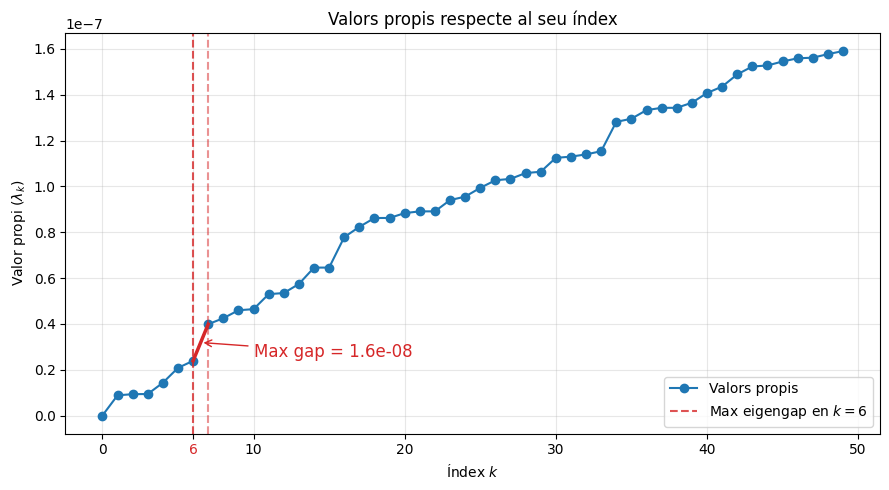

In [29]:
grafica_eigenvalues_vs_index(vaps, subfolder="autonom")

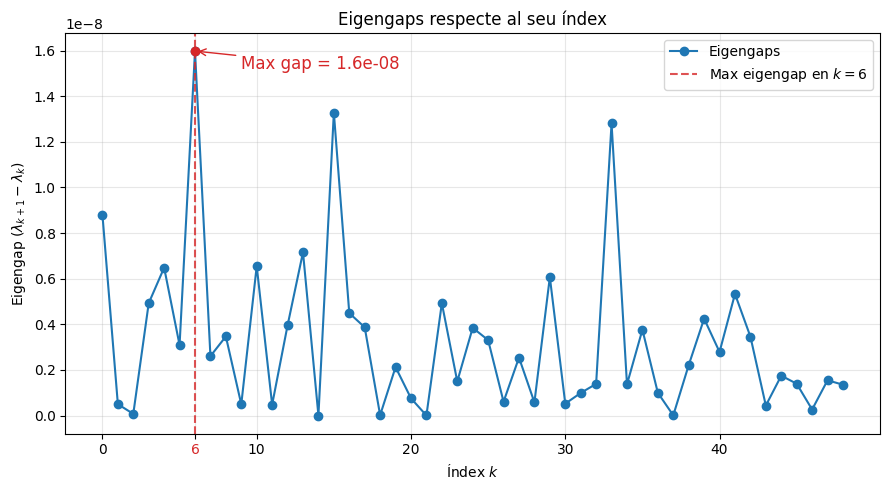

In [30]:
grafica_eigengaps_vs_index(vaps, subfolder="autonom")

In [31]:
num_clusters, diff_max = calcula_num_clusters_i_max_eigengap(vaps)

In [32]:
print(f"Nombre de clusters suggerit per l'heurística del màxim eigengap: {num_clusters}")
print(f"Valor del màxim eigengap: {diff_max:.3e}") # use scientific notation for small values

Nombre de clusters suggerit per l'heurística del màxim eigengap: 8
Valor del màxim eigengap: 2.604e-09


In [33]:
labels = troba_clusters(num_clusters, veps)

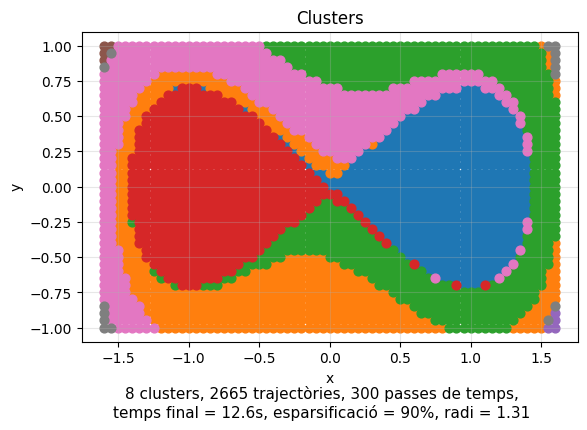

In [34]:
grafica_clusters(condicions_inicials, labels, num_clusters, radi_esparsificacio, 
                 sparsification_percent, params, subfolder="autonom")

##### Opció B: triar radi d'esparsificació que maximitza la diferència màxima entre VAPs consecutius

In [35]:
result = calcula_diffs_vs_radis(matriu_pesos, constant_diagonal, params)

In [36]:
indexs_max_rel = troba_indexs_max_rel(result.normalized_eigengaps)
print("indexs_max_rel =", indexs_max_rel)
print("radis[indexs_max_rel] =", result.radis[indexs_max_rel])

indexs_max_rel = [5, 22, 28, 37, 40]
radis[indexs_max_rel] = [0.454 0.971 1.153 1.426 1.517]


Maxim_relatiu_num 1
Radi: 0.454, Esparsificació: 3.74%, Clusters: 2, Max Eigen gap: 4.21472e-08


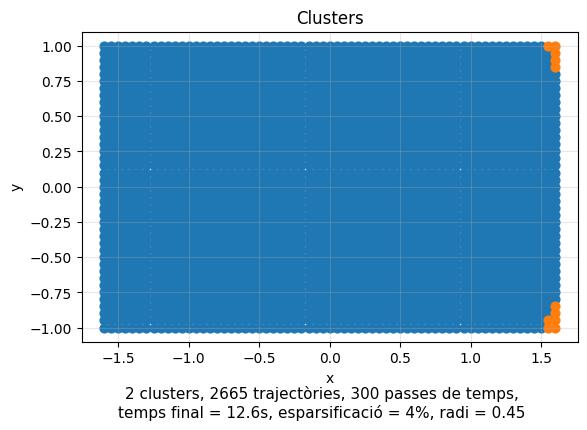

Maxim_relatiu_num 2
Radi: 0.971, Esparsificació: 82.25%, Clusters: 2, Max Eigen gap: 4.47060e-09


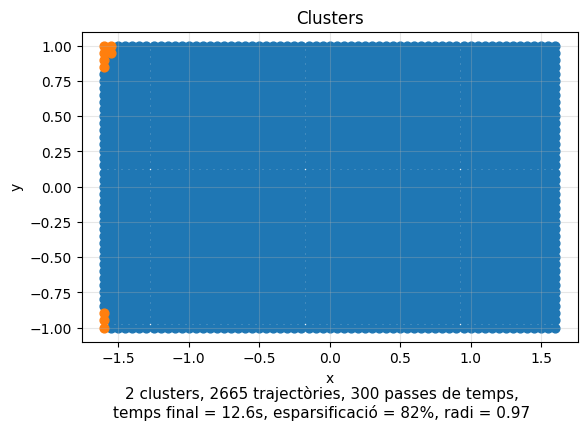

Maxim_relatiu_num 3
Radi: 1.153, Esparsificació: 87.46%, Clusters: 2, Max Eigen gap: 2.31502e-09


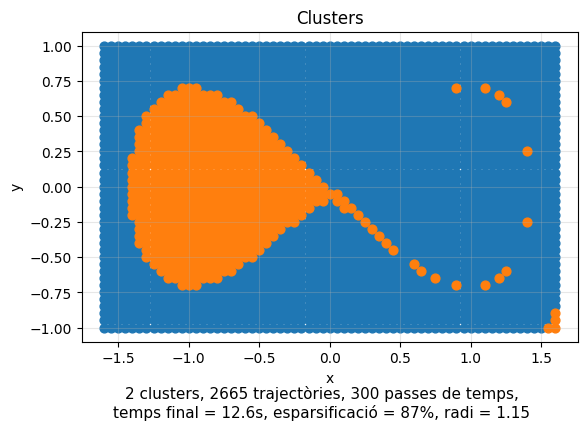

Maxim_relatiu_num 4
Radi: 1.426, Esparsificació: 91.64%, Clusters: 8, Max Eigen gap: 2.36916e-09


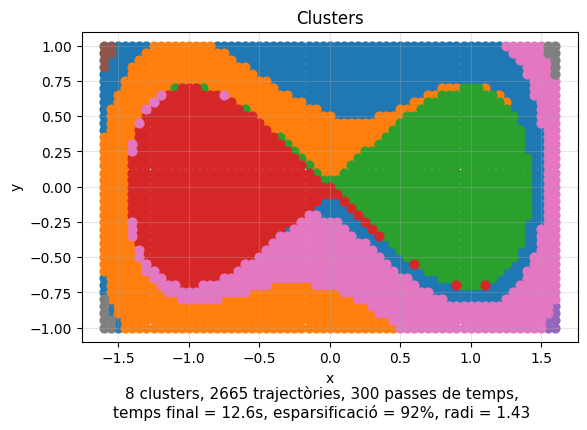

Maxim_relatiu_num 5
Radi: 1.517, Esparsificació: 92.79%, Clusters: 8, Max Eigen gap: 2.30183e-09


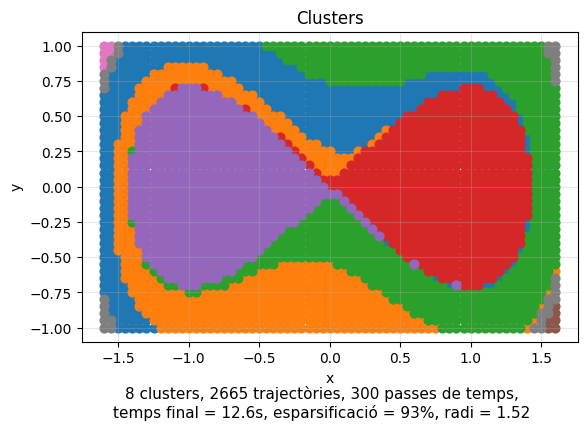

In [37]:
grafica_clusters_maxs_rel(indexs_max_rel, result, condicions_inicials, 
                          params, subfolder="autonom_maxs_rels")

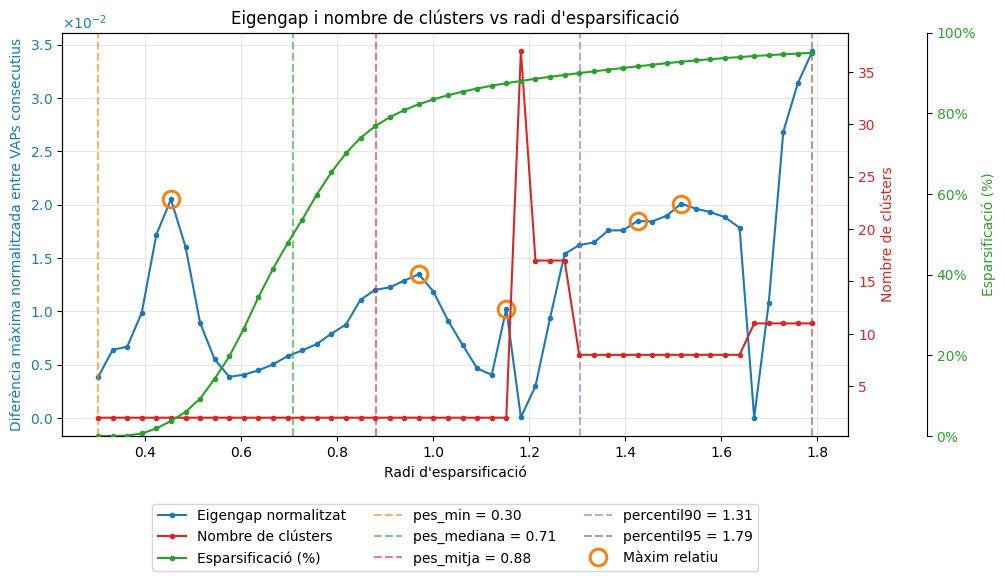

In [38]:
grafica_eigengaps_vs_radi(result, params, subfolder="autonom_maxs_rels", indexs_max_rel=indexs_max_rel)